In [1]:
import os
import pandas as pd
from transformers import AutoTokenizer
from nltk.tokenize import word_tokenize
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from datasets import load_dataset

import sys
print("Python executable:", sys.executable)


from collections import Counter



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python executable: c:\Users\ASUS\AppData\Local\Programs\Python\Python312\python.exe


In [2]:
folder_path = "MADAR_Corpus-20241228T103322Z-001\MADAR_Corpus"
dataframes =[]
for filename in os.listdir(folder_path):
    if filename.endswith(".tsv"):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path, sep='\t')
        dataframes.append(df)
combined_data = pd.concat(dataframes,ignore_index=True)
combined_data = combined_data.drop_duplicates().dropna()
def split(value):
    if value.endswith("test"):
        return "test"
    elif value.endswith("train"):
        return "train"
    elif value.endswith("dev"):
        return "valid"
    else:
        return "unknown"


combined_data['split'] = combined_data['split'].apply(split)
combined_data.head(10)


splits = {
    'train': 'hf://datasets/Abdelrahman-Rezk/Arabic_Dialect_Identification/data/train-00000-of-00001.parquet',
    'validation': 'hf://datasets/Abdelrahman-Rezk/Arabic_Dialect_Identification/data/validation-00000-of-00001.parquet',
    'test': 'hf://datasets/Abdelrahman-Rezk/Arabic_Dialect_Identification/data/test-00000-of-00001.parquet'
}
train_data2 = pd.read_parquet(splits['train'])
valid_data2 = pd.read_parquet(splits['validation'])
test_data2 = pd.read_parquet(splits['test'])
dialect_map = {
    0: 'OM', 1: 'SD', 2: 'SA', 3: 'KW', 4: 'QA',
    5: 'LB', 6: 'JO', 7: 'SY', 8: 'IQ', 9: 'MA',
    10: 'EG', 11: 'PL', 12: 'YE', 13: 'BH', 14: 'DZ',   
    15: 'AE', 16: 'TN', 17: 'LY'
}
train_data2['lang'] = train_data2['label'].map(dialect_map)
test_data2['lang'] = test_data2['label'].map(dialect_map)
valid_data2['lang'] = valid_data2['label'].map(dialect_map)
print('\nQADI Columns:\n')

train_data2= train_data2.drop_duplicates().dropna()
test_data2= test_data2.drop_duplicates().dropna()
valid_data2= valid_data2.drop_duplicates().dropna()
train_data2



<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_31728\4167118427.py:1: SyntaxWarning: invalid escape sequence '\M'
  folder_path = "MADAR_Corpus-20241228T103322Z-001\MADAR_Corpus"



QADI Columns:



,id,label,text,lang
0,1046024946705735552,9,@Ahmed_Hamza27 اتمنى صراحة و خصوصا #طال_عمره ب...,MA
1,1140189387508134016,17,@rJiM4CnIFTgml9g @zamnissi طبعا عرفته من اللي ...,LY
2,1051416181855440768,0,@OmanisFollowers @ooredoo @TRA_OMAN @motc_om ه...,OM
3,781770259422412800,11,كلب شو كنتوا بتتوقعوا منه !؟ \n\nمحمود عباس لا...,PL
4,968140551366340608,11,#عزام 🔊\nاحنا ابو الولد وام الولد,PL
...,...,...,...,...
440047,1024415002810306560,6,انت مش مجبور تجامل حدا وتعطيه اكبر من حجمه ؛ ع...,JO
440048,825422832138067968,3,رتم الفريق بدون جيرو سريييييييييع ، مع جيرو يص...,KW
440049,1137082760726810624,2,🇸🇦💚🇸🇦💚🇸🇦\nksa\n👆🏻\nوغير هالبلد قلبي ما عشق ولا...,SA
440050,1075003837436575616,11,@a7lawa7di @ranim2298 خلص اذا هيييك بطلت ادعي ...,PL


In [3]:
file_path = "dialect_name_unification.xlsx"
df = pd.read_excel(file_path)
df = df.drop(index=0)
df = df.drop(index=1)

df = df.dropna(subset=['City'])
df.rename(columns={'Unnamed: 0': 'Region1'}, inplace=True)
df.rename(columns={'Unnamed: 2': 'Region2'}, inplace=True)
df.rename(columns={'Unnamed: 3': 'Country1'}, inplace=True)
df.rename(columns={'Unnamed: 5': 'Country2'}, inplace=True)
df.rename(columns={'Unnamed: 6': 'City1'}, inplace=True)
df.rename(columns={'Unnamed: 8': 'City2'}, inplace=True)
combined_data = pd.merge(combined_data, df[['City1','Country', 'Region']], how='left', left_on='lang', right_on='City1')
train_data2 = pd.merge(train_data2, df[['Country1','Country', 'Region']], how='left', left_on='lang', right_on='Country1')
test_data2 = pd.merge(test_data2, df[['Country1','Country', 'Region']], how='left', left_on='lang', right_on='Country1')
valid_data2 = pd.merge(valid_data2, df[['Country1','Country', 'Region']], how='left', left_on='lang', right_on='Country1')



In [4]:
train_data = combined_data[combined_data['split'] == 'train']
valid_data = combined_data[combined_data['split'] == 'valid']
test_data = combined_data[combined_data['split'] == 'test']

df_train = pd.concat([train_data,train_data2]).drop_duplicates()
df_test = pd.concat([test_data,test_data2]).drop_duplicates()
df_valid =pd.concat([valid_data,valid_data2]).drop_duplicates()
df_train['sents'] = df_train['sent'].fillna(df_train['text'])
df_test['sents'] = df_test['sent'].fillna(df_test['text'])
df_valid['sents'] = df_valid['sent'].fillna(df_valid['text'])

df_train['ID'] = df_train['sentID.BTEC'].fillna(df_train['id'])
df_test['ID'] = df_test['sentID.BTEC'].fillna(df_test['id'])
df_valid['ID'] = df_valid['sentID.BTEC'].fillna(df_valid['id'])

df_train
df_train = df_train.drop(columns=['sent', 'text', 'Country1','sentID.BTEC','id'])
df_test = df_test.drop(columns=['sent', 'text' ,'Country1','sentID.BTEC','id'])
df_valid = df_valid.drop(columns=['sent', 'text' ,'Country1','sentID.BTEC','id'])



df_train

,split,lang,City1,Country,Region,label,sents,ID
0,train,ALE,ALE,Syria,Levant,NaN,هو هنيك، قدام معلومات السياح بالضبط.,5.000000e+00
1,train,ALE,ALE,Syria,Levant,NaN,مالي سمعان من قبل بهالعنوان هون.,9.000000e+00
2,train,ALE,ALE,Syria,Levant,NaN,روح ساوي لبين ما تشوف صيدلية.,1.100000e+01
3,train,ALE,ALE,Syria,Levant,NaN,بشقد الفطور؟,2.600000e+01
4,train,ALE,ALE,Syria,Levant,NaN,شلون بقدر أساعدك؟,2.700000e+01
...,...,...,...,...,...,...,...,...
761267,NaN,JO,NaN,Jordan,Levant,6.0,انت مش مجبور تجامل حدا وتعطيه اكبر من حجمه ؛ ع...,1.024415e+18
761269,NaN,KW,NaN,NaN,NaN,3.0,رتم الفريق بدون جيرو سريييييييييع ، مع جيرو يص...,8.254228e+17
761270,NaN,SA,NaN,Saudi Arabia,Gulf,2.0,🇸🇦💚🇸🇦💚🇸🇦\nksa\n👆🏻\nوغير هالبلد قلبي ما عشق ولا...,1.137083e+18
761272,NaN,PL,NaN,Palestine,Levant,11.0,@a7lawa7di @ranim2298 خلص اذا هيييك بطلت ادعي ...,1.075004e+18


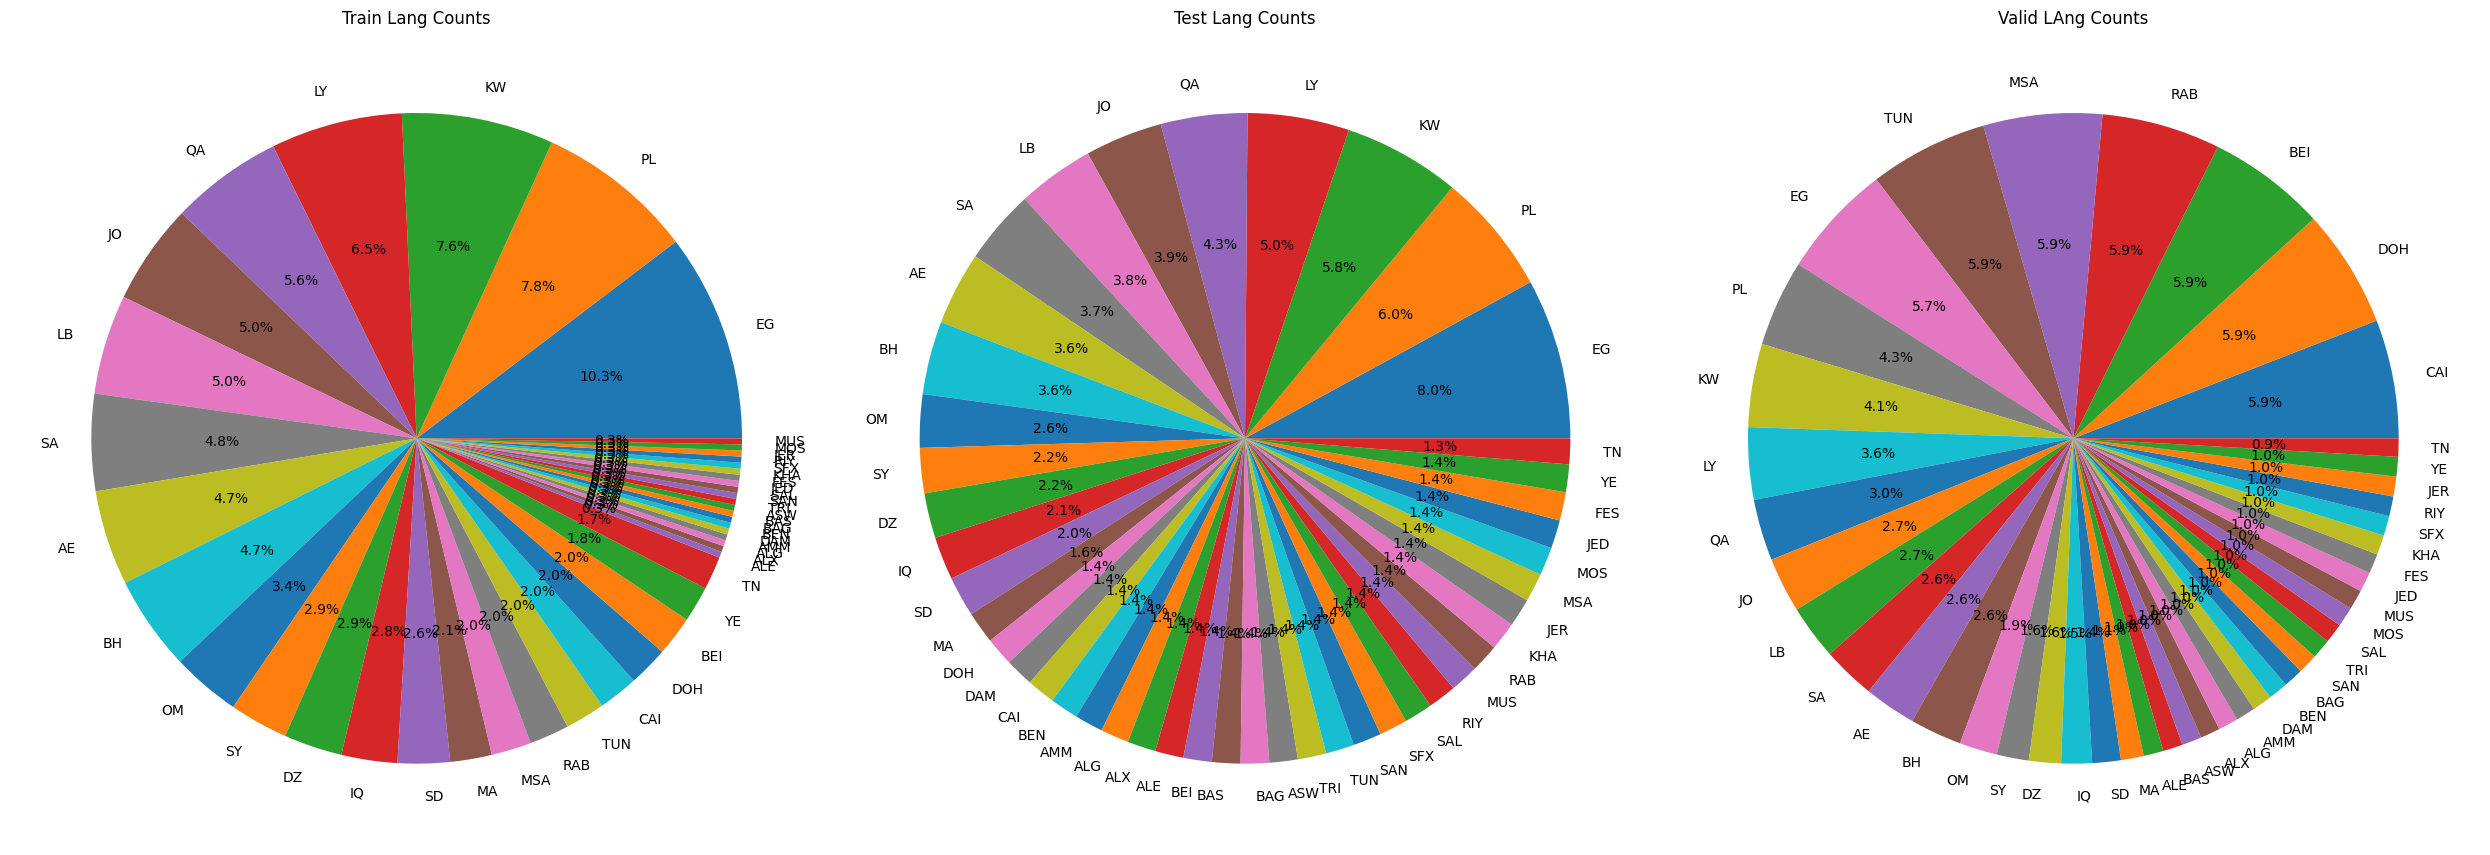

In [5]:
import matplotlib.pyplot as plt

counts_train = df_train['lang'].value_counts()
counts_test = df_test['lang'].value_counts()
counts_valid = df_valid['lang'].value_counts()


fig, axes = plt.subplots(1, 3, figsize=(25, 12))

axes[0].pie(counts_train, labels=counts_train.index, autopct='%1.1f%%')
axes[0].set_title("Train Lang Counts")

axes[1].pie(counts_test,labels = counts_test.index, autopct='%1.1f%%')
axes[1].set_title("Test Lang Counts")

axes[2].pie(counts_valid,labels = counts_valid.index, autopct='%1.1f%%')
axes[2].set_title("Valid LAng Counts")
plt.tight_layout()

plt.show()



here we note that the

In [6]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
tokenizer = AutoTokenizer.from_pretrained("CAMeL-Lab/arabart-qalb14-gec-ged-13")
df_train['tokens'] = df_train['sents'].apply(lambda x: tokenizer.tokenize(str(x)))


In [7]:
df_test['tokens'] = df_test['sents'].apply(lambda x: tokenizer.tokenize(str(x)))
df_valid['tokens'] = df_valid['sents'].apply(lambda x: tokenizer.tokenize(str(x)))

In [8]:
word_count1=  df_train['tokens'].apply(len)
#word_count2=  df_train['tokenzied_text'].apply(len)
total_word_count1 = word_count1.sum()
#total_word_count2 = word_count2.sum()
print('Total word count1:', total_word_count1)
#print('Total word count2', total_word_count2)
all_words1 = [word for tokens in df_train['tokens'] for word in tokens]
#all_words2 = [word for tokens in df_train['tokenzied_text'] for word in tokens]

unique_words1 = set(all_words1)
#unique_words2 = set(all_words2)

print ('Number of unique words 1:', len(unique_words1))
#print ('Number of unique words 2:', len(unique_words2))
#print((df_train['tokenzied_text'][0])

Total word count1: 14884861
Number of unique words 1: 69124


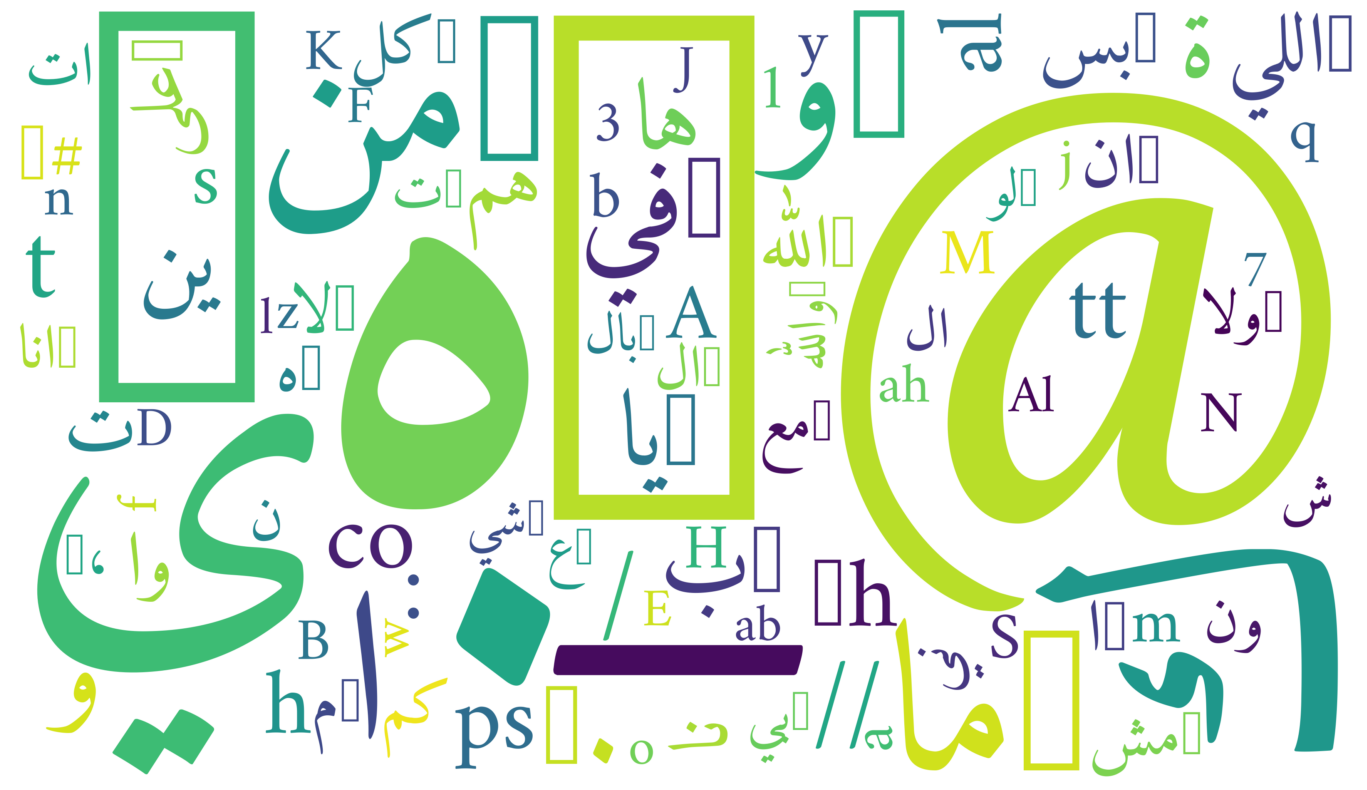

In [9]:
import seaborn as sns
from collections import Counter
import arabic_reshaper
from bidi.algorithm import get_display
from wordcloud import WordCloud, ImageColorGenerator

word_freq = Counter(all_words1)

top_100 = dict(word_freq.most_common(100))

font_file = "Amiri-Regular.ttf"
stopwords_csv = "arabic_dialects_stopwords.csv"
stopwords = pd.read_csv(stopwords_csv)["word"].tolist()
stopwords = [arabic_reshaper.reshape(s) for s in stopwords]

word_freq_dict = {get_display(arabic_reshaper.reshape(word)): freq 
                  for word, freq in top_100.items()
                  if word not in stopwords}



wordcloud = WordCloud(
    font_path= font_file,
    width=3500,
    height=2000,
    random_state=1,
    background_color='white',
    collocations=False,
    stopwords=stopwords
).generate_from_frequencies(word_freq_dict)

plt.figure(figsize=(20,10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [10]:
import os
import pandas as pd
from transformers import AutoTokenizer
from nltk.tokenize import word_tokenize
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from datasets import load_dataset

import sys
print("Python executable:", sys.executable)


from collections import Counter



Python executable: c:\Users\ASUS\AppData\Local\Programs\Python\Python312\python.exe


In [11]:
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder ,TrigramAssocMeasures,TrigramCollocationFinder

def find_n(tokenized_text,n=1,x=1):
   N = Counter(tokenized_text)
   if x==1:
      most_common_words = N.most_common(n)
      return most_common_words
   elif x==2:
      less_common_words = N.most_common()[-n:] 
      return less_common_words
   elif x==3:
       bigram = [(tokenized_text[i], tokenized_text[i+1]) for i in range(len(tokenized_text)-1)]
       N =Counter(bigram)
       most_common_bigram= N.most_common()
       return most_common_bigram
   elif x==4:
       trigrams = [(tokenized_text[i], tokenized_text[i + 1], tokenized_text[i + 2]) for i in range(len(tokenized_text) - 2)]
       N = Counter(trigrams)
       most_common_trigrams = N.most_common(n)    
       return most_common_trigrams
   elif x == 5:  
        bigram_coll = BigramAssocMeasures()
        finder = BigramCollocationFinder.from_words(tokenized_text)
        important_bigrams = finder.nbest(bigram_coll.pmi, n) 
        return important_bigrams
   elif x==6:
         trigram_coll = TrigramAssocMeasures()
         finder = TrigramCollocationFinder.from_words(tokenized_text)
         important_trigram = finder.nbest(trigram_coll.pmi,n)
         return important_trigram
   
   
tokens = df_train['tokens'].sample(1).iloc[0]
tokens = [item for sublist in tokens for item in sublist]  
most = find_n(tokens, 10,1)
less = find_n(tokens, 10,2)  
most_bigram = find_n(tokens, 10,3)
most_trigram = find_n(tokens, 10,4)
important_bigrams = find_n(tokens, 10, 5)  
important_trigrams = find_n(tokens, 10, 6)  


print("Most repeated words:",most)
print("Less repeated words:",less)
print("Most Common Bigram",most_bigram)
print("Most Common Trigram",most_trigram)
print("Collection Bigram:",important_bigrams)
print("Collection Trigram:",important_trigrams)
print(df_train.columns)

Most repeated words: [('▁', 11), ('ه', 8), ('ن', 6), ('ا', 5), ('ل', 4), ('ي', 3), ('t', 3), ('/', 3), ('س', 2), ('ف', 2)]
Less repeated words: [('c', 1), ('o', 1), ('q', 1), ('P', 1), ('0', 1), ('6', 1), ('7', 1), ('Q', 1), ('H', 1), ('J', 1)]
Most Common Bigram [(('ه', 'ه'), 6), (('▁', 'ا'), 3), (('ا', 'ل'), 3), (('ن', '▁'), 2), (('ي', '▁'), 2), (('ه', '▁'), 2), (('ل', 'ن'), 1), (('ن', 'ق'), 1), (('ق', 'ص'), 1), (('ص', 'ا'), 1), (('ا', 'ن'), 1), (('▁', 'ب'), 1), (('ب', 'س'), 1), (('س', '▁'), 1), (('ل', 'س'), 1), (('س', 'ن'), 1), (('ن', 'ة'), 1), (('ة', '▁'), 1), (('▁', 'م'), 1), (('م', 'د'), 1), (('د', 'ر'), 1), (('ر', 'ي'), 1), (('▁', 'ه'), 1), (('▁', 'إ'), 1), (('إ', 'ن'), 1), (('▁', 'ش'), 1), (('ش', 'ا'), 1), (('ا', 'ء'), 1), (('ء', '▁'), 1), (('ل', 'ل'), 1), (('ل', 'ه'), 1), (('▁', 'ن'), 1), (('ن', 'خ'), 1), (('خ', 'ف'), 1), (('ف', 'ف'), 1), (('ف', '▁'), 1), (('▁', 'ي'), 1), (('ي', 'ع'), 1), (('ع', 'ن'), 1), (('ن', 'ي'), 1), (('▁', 'h'), 1), (('h', 't'), 1), (('t', 't'), 1), (('t

الفرق بين الأكثر تكرارًا والكلمات المهمة (Collocations):

الأكثر تكرارًا: يعكس عدد المرات التي تظهر فيها الكلمة أو العبارة في النص.
الكلمات المهمة (Collocations): تعكس مدى الترابط القوي أو العلاقة الإحصائية بين الكلمات المتتالية، وليس فقط تكرارها. يمكن أن تكون بعض الكلمات المتكررة بشكل كبير غير ذات صلة قوية إذا لم تظهر معًا بشكل متوقع أكثر مما هو عشوائي.

In [12]:
def find_freq_dia(df, dialect_value, level='City'):
    if level == 'City':
        filtered_df = df[df['lang'] == dialect_value]
    elif level == 'Region':
        filtered_df = df[df['Region'] == dialect_value]
    elif level == 'Country':
        filtered_df = df[df['Country'] == dialect_value]
    

    all_tokens = []
    for tokens in filtered_df['tokens']:
        all_tokens.extend(tokens)
    
    word_counts = Counter(all_tokens)
    
    most_common_word = word_counts.most_common(10)
    
    return most_common_word,
most_common_word_city = find_freq_dia(df_train, "ALE", level='City')
most_common_word_region = find_freq_dia(df_train, "Levant", level='Region')
most_common_word_country = find_freq_dia(df_train, "Saudi Arabia", level='Country')

print("Most frequent word in City: ", most_common_word_city)
print("Most frequent word in Region: ", most_common_word_region)
print("Most frequent word in Country: ", most_common_word_country)


Most frequent word in City:  ([('.', 1253), ('؟', 683), ('،', 400), ('▁إذا', 250), ('▁سمحت', 210), ('▁ب', 204), ('ك', 179), ('ي', 178), ('▁بدي', 164), ('▁من', 161)],)
Most frequent word in Region:  ([('▁@', 86997), ('ه', 85470), ('▁', 59434), ('ي', 45755), ('.', 42335), ('_', 39867), ('ك', 36784), ('ا', 33374), ('و', 31790), ('▁ما', 31347)],)
Most frequent word in Country:  ([('ه', 33620), ('▁@', 25597), ('_', 15906), ('▁', 12499), ('ي', 10195), ('.', 9396), ('ك', 8751), ('▁من', 7785), ('▁ما', 6671), ('▁و', 6448)],)


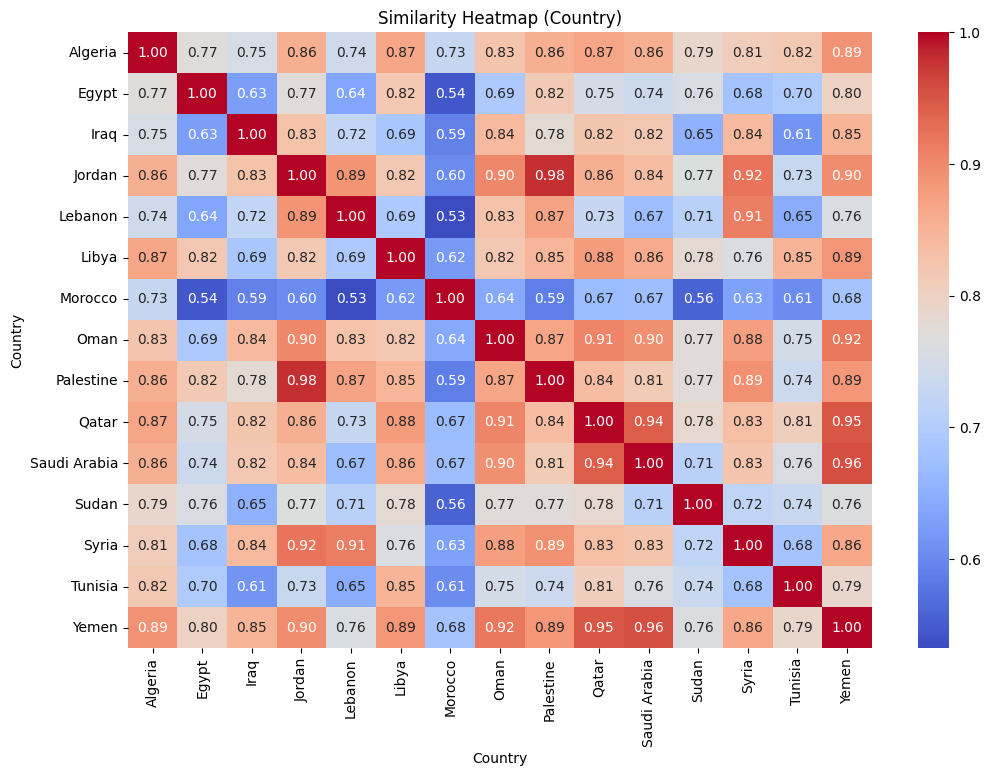

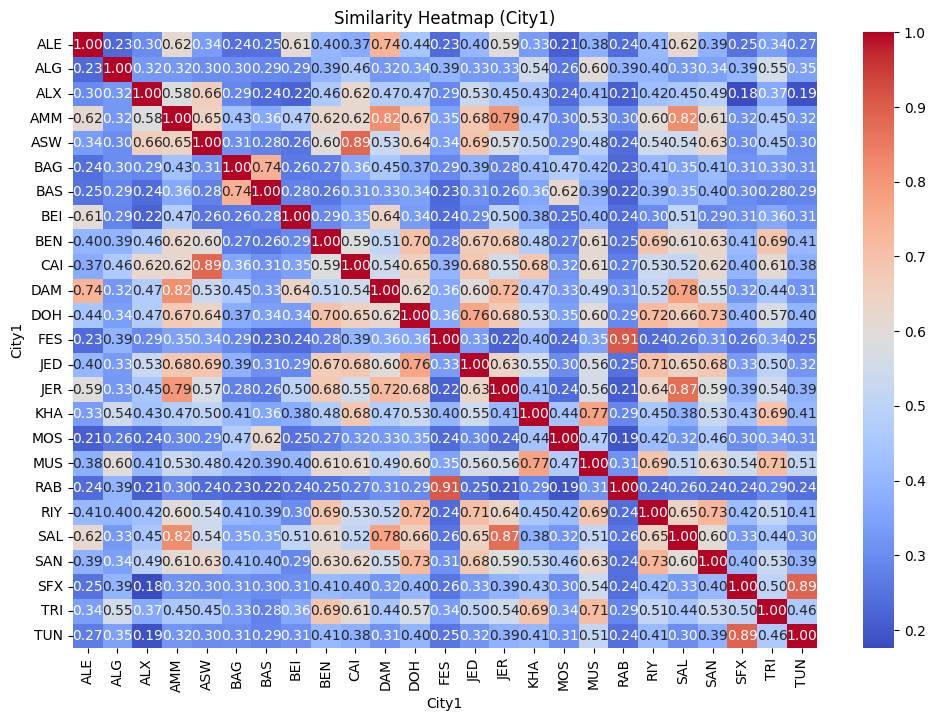

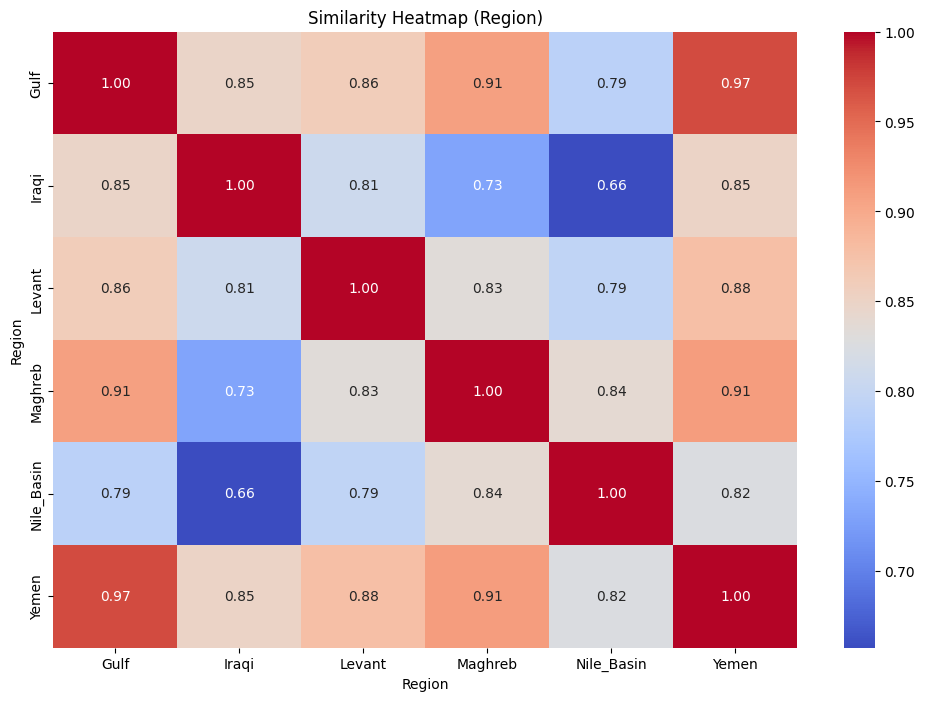

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_similarity(df, group_column, max_features=1000):

    def clean_text(text):
        import re
        text = re.sub(r'[^\w\s]', '', text)  
        return text
    
    df['sents_clean'] = df['sents'].apply(clean_text)
    grouped_data = df.groupby(group_column)['sents_clean'].apply(' '.join)
    
    count_vec = CountVectorizer(max_features=max_features)
    count_matrix = count_vec.fit_transform(grouped_data)
    similarity = cosine_similarity(count_matrix)
    
    labels = grouped_data.index
    similarity_df = pd.DataFrame(similarity, index=labels, columns=labels)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(similarity_df, cmap='coolwarm', annot=True, fmt=".2f")
    plt.title(f'Similarity Heatmap ({group_column})')
    plt.show()
    
    return similarity_df
country_similarity = analyze_similarity(df_train, 'Country', max_features=1000)
city_similarity = analyze_similarity(df_train, 'City1', max_features=1000)
Region_similarity = analyze_similarity(df_train, 'Region', max_features=1000)




لاحظت ان البلدان قريبه من بعضها البعض تتشابه من حيث اللهجه بنسبه معينه حيث ان بلاد الشام نلاحظ ان الفرق بين سوريا والاردن هو فرض قليل جدا وهذا ما يوضح النقطه التي اتحدث عنها

In [14]:
import re

def remove_special_characters(text):
    return re.sub(r"[^\u0621-\u064A\s0-9]", "", text)

print([remove_special_characters(x) for x in df_train['sents'][:5]])


['هو هنيك قدام معلومات السياح بالضبط', 'مالي سمعان من قبل بهالعنوان هون', 'روح ساوي لبين ما تشوف صيدلية', 'بشقد الفطور', 'شلون بقدر أساعدك']


In [15]:
def remove_numbers(text):
    return re.sub(r"\d+", "", text)

print([remove_numbers(x) for x in df_train['sents'][:5]])


['هو هنيك، قدام معلومات السياح بالضبط.', 'مالي سمعان من قبل بهالعنوان هون.', 'روح ساوي لبين ما تشوف صيدلية.', 'بشقد الفطور؟', 'شلون بقدر أساعدك؟']


In [16]:
def normalize_whitespace(text):
    return re.sub(r"\s+", " ", text).strip()

print([normalize_whitespace(x) for x in df_train['sents'][:5]])


['هو هنيك، قدام معلومات السياح بالضبط.', 'مالي سمعان من قبل بهالعنوان هون.', 'روح ساوي لبين ما تشوف صيدلية.', 'بشقد الفطور؟', 'شلون بقدر أساعدك؟']


In [17]:
def remove_english_words(text):
    return re.sub(r"[a-zA-Z]+", "", text)

print([remove_english_words(x) for x in df_train['sents'][:5]])



['هو هنيك، قدام معلومات السياح بالضبط.', 'مالي سمعان من قبل بهالعنوان هون.', 'روح ساوي لبين ما تشوف صيدلية.', 'بشقد الفطور؟', 'شلون بقدر أساعدك؟']


In [18]:
def remove_repeated_phrases(text):
    return re.sub(r"(\b\w+\b)( \1)+", r"\1", text)

print([remove_repeated_phrases(x) for x in df_train['sents'][:5]])


['هو هنيك، قدام معلومات السياح بالضبط.', 'مالي سمعان من قبل بهالعنوان هون.', 'روح ساوي لبين ما تشوف صيدلية.', 'بشقد الفطور؟', 'شلون بقدر أساعدك؟']


In [19]:
def normalize_arabic_characters(text):
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    return text

print([normalize_arabic_characters(x) for x in df_train['sents'][:5]])


['هو هنيك، قدام معلومات السياح بالضبط.', 'مالي سمعان من قبل بهالعنوان هون.', 'روح ساوي لبين ما تشوف صيدلية.', 'بشقد الفطور؟', 'شلون بقدر اساعدك؟']


In [20]:
def remove_diacritics(text):
    return re.sub(r"[\u064B-\u065F]", "", text)

print([remove_diacritics(x) for x in df_train['sents'][:5]])


['هو هنيك، قدام معلومات السياح بالضبط.', 'مالي سمعان من قبل بهالعنوان هون.', 'روح ساوي لبين ما تشوف صيدلية.', 'بشقد الفطور؟', 'شلون بقدر أساعدك؟']


In [21]:
ARABIC_STOP_WORDS = set([
    "في", "على", "من", "إلى", "عن", "ما", "و", "يا", "أن", "إن", 
    "لكن", "أو", "لا", "كل", "قد", "هذا", "هذه", "كان", "كانوا"
])

def remove_stop_words(text):
    return " ".join([word for word in text.split() if word not in ARABIC_STOP_WORDS])

print([remove_stop_words(x) for x in df_train['sents'][:5]])


['هو هنيك، قدام معلومات السياح بالضبط.', 'مالي سمعان قبل بهالعنوان هون.', 'روح ساوي لبين تشوف صيدلية.', 'بشقد الفطور؟', 'شلون بقدر أساعدك؟']


In [22]:
from camel_tools.utils.dediac import dediac_ar
from camel_tools.tokenizers.word import simple_word_tokenize

def arabic_stemming(text):
    text = dediac_ar(text)
    tokens = simple_word_tokenize(text)
    return " ".join(tokens)

print([arabic_stemming(x) for x in df_train['sents'][:5]])


['هو هنيك ، قدام معلومات السياح بالضبط .', 'مالي سمعان من قبل بهالعنوان هون .', 'روح ساوي لبين ما تشوف صيدلية .', 'بشقد الفطور ؟', 'شلون بقدر أساعدك ؟']


In [23]:
def clean_text(text, functions):
    for func in functions:
        text = func(text)
    return text

functions_list = [arabic_stemming,remove_special_characters, remove_numbers, normalize_whitespace, remove_english_words, normalize_arabic_characters ,remove_repeated_phrases,remove_diacritics,remove_stop_words]

print([clean_text(x, functions_list) for x in df_train['sents'][:5]])



['هو هنيك قدام معلومات السياح بالضبط', 'مالي سمعان قبل بهالعنوان هون', 'روح ساوي لبين تشوف صيدلية', 'بشقد الفطور', 'شلون بقدر اساعدك']


In [24]:
df_train['cleaned_sents'] = df_train['sents'].apply(lambda x: clean_text(x, functions_list))

from collections import Counter

def count_words(text):
    return len(text.split())

total_words_before = df_train['sents'].apply(count_words).sum()
unique_words_before = len(set(" ".join(df_train['sents']).split()))

total_words_after = df_train['cleaned_sents'].apply(count_words).sum()
unique_words_after = len(set(" ".join(df_train['cleaned_sents']).split()))

print("Total words before cleaning:", total_words_before)
print("Unique words before cleaning:", unique_words_before)
print("Total words after cleaning:", total_words_after)
print("Unique words after cleaning:", unique_words_after)


Total words before cleaning: 7156986
Unique words before cleaning: 913009
Total words after cleaning: 5864216
Unique words after cleaning: 461698


نلاحظ اننا قمنا بتخفيف عدد من كلمات الداتا وهذا شيء جيد

In [25]:
short_texts_count = df_train[df_train['cleaned_sents'].str.len() < 5].shape[0]
df_train = df_train[df_train['cleaned_sents'].str.len() >= 5]

print("Number of short texts removed:", short_texts_count)


Number of short texts removed: 946


In [26]:

df_train['cleaned_sents'] = df_train['sents'].apply(lambda x: clean_text(x, functions_list))
df_test['cleaned_sents'] = df_test['sents'].apply(lambda x: clean_text(x, functions_list))
print(df_train.columns)
print(df_test.columns)



C:\Users\ASUS\AppData\Local\Temp\ipykernel_31728\2447945705.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['cleaned_sents'] = df_train['sents'].apply(lambda x: clean_text(x, functions_list))


Index(['split', 'lang', 'City1', 'Country', 'Region', 'label', 'sents', 'ID',
       'tokens', 'sents_clean', 'cleaned_sents'],
      dtype='object')
Index(['split', 'lang', 'City1', 'Country', 'Region', 'label', 'sents', 'ID',
       'tokens', 'cleaned_sents'],
      dtype='object')


In [27]:
train_X, train_Y = df_train['sents'], df_train['lang']
valid_X, valid_Y = df_valid['sents'], df_valid['lang']
test_X, test_Y = df_test['sents'], df_test['lang']


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, f1_score

def train_and_evaluate_naive_bayes(train_X, train_Y, valid_X, valid_Y):

    tfidf_vectorizer = TfidfVectorizer(max_features=5000)  
    X_train_tfidf = tfidf_vectorizer.fit_transform(train_X)
    X_valid_tfidf = tfidf_vectorizer.transform(valid_X)

    nb_model = MultinomialNB()
    nb_model.fit(X_train_tfidf, train_Y)

    train_preds = nb_model.predict(X_train_tfidf)
    valid_preds = nb_model.predict(X_valid_tfidf)

    train_accuracy = accuracy_score(train_Y, train_preds)
    valid_accuracy = accuracy_score(valid_Y, valid_preds)

    valid_f1 = f1_score(valid_Y, valid_preds, average='weighted')

    print("Train Accuracy:", train_accuracy)
    print("Validation Accuracy:", valid_accuracy)
    print("Validation F1-Score:", valid_f1)

    return {
        'model': nb_model,
        'vectorizer': tfidf_vectorizer,
        'train_accuracy': train_accuracy,
        'valid_accuracy': valid_accuracy,
        'valid_f1': valid_f1
    }

result_raw = train_and_evaluate_naive_bayes(train_X, train_Y, valid_X, valid_Y)


Train Accuracy: 0.46654797215666177
Validation Accuracy: 0.444706344529562
Validation F1-Score: 0.4114705738203484


In [29]:
results = {
    'Model': ['Naive Bayes'],
    'Processing': ['Raw Data'],
    'Train Accuracy': [result_raw['train_accuracy']],
    'Validation Accuracy': [result_raw['valid_accuracy']],
    'Validation F1-Score': [result_raw['valid_f1']]
}

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)


         Model Processing  Train Accuracy  Validation Accuracy  \
0  Naive Bayes   Raw Data        0.466548             0.444706   

   Validation F1-Score  
0             0.411471  


In [30]:
def apply_cleaning_operations(text, operations):
    for operation in operations:
        text = operation(text)
    return text

cleaned_train_X = train_X.apply(lambda x: apply_cleaning_operations(x, [remove_special_characters]))
cleaned_valid_X = valid_X.apply(lambda x: apply_cleaning_operations(x, [remove_special_characters]))

result_cleaned = train_and_evaluate_naive_bayes(cleaned_train_X, train_Y, cleaned_valid_X, valid_Y)

results['Model'].append('Naive Bayes')
results['Processing'].append('Diacritics Removal + Stop Words Removal')
results['Train Accuracy'].append(result_cleaned['train_accuracy'])
results['Validation Accuracy'].append(result_cleaned['valid_accuracy'])
results['Validation F1-Score'].append(result_cleaned['valid_f1'])





Train Accuracy: 0.4591813071108235
Validation Accuracy: 0.4392064427420939
Validation F1-Score: 0.4055792348880476


In [31]:
cleaned_train_X = train_X.apply(lambda x: apply_cleaning_operations(x, [remove_numbers]))
cleaned_valid_X = valid_X.apply(lambda x: apply_cleaning_operations(x, [remove_numbers]))

result_cleaned = train_and_evaluate_naive_bayes(cleaned_train_X, train_Y, cleaned_valid_X, valid_Y)

results['Model'].append('Naive Bayes')
results['Processing'].append('Diacritics Removal + Stop Words Removal')
results['Train Accuracy'].append(result_cleaned['train_accuracy'])
results['Validation Accuracy'].append(result_cleaned['valid_accuracy'])
results['Validation F1-Score'].append(result_cleaned['valid_f1'])

Train Accuracy: 0.4670061678754306
Validation Accuracy: 0.44465723826360243
Validation F1-Score: 0.41144177026453277


In [32]:
cleaned_train_X = train_X.apply(lambda x: apply_cleaning_operations(x, [normalize_whitespace]))
cleaned_valid_X = valid_X.apply(lambda x: apply_cleaning_operations(x, [normalize_whitespace]))

result_cleaned = train_and_evaluate_naive_bayes(cleaned_train_X, train_Y, cleaned_valid_X, valid_Y)

results['Model'].append('Naive Bayes')
results['Processing'].append('Diacritics Removal + Stop Words Removal')
results['Train Accuracy'].append(result_cleaned['train_accuracy'])
results['Validation Accuracy'].append(result_cleaned['valid_accuracy'])
results['Validation F1-Score'].append(result_cleaned['valid_f1'])

Train Accuracy: 0.46654797215666177
Validation Accuracy: 0.444706344529562
Validation F1-Score: 0.4114705738203484


In [33]:
cleaned_train_X = train_X.apply(lambda x: apply_cleaning_operations(x, [remove_english_words]))
cleaned_valid_X = valid_X.apply(lambda x: apply_cleaning_operations(x, [remove_english_words]))

result_cleaned = train_and_evaluate_naive_bayes(cleaned_train_X, train_Y, cleaned_valid_X, valid_Y)

results['Model'].append('Naive Bayes')
results['Processing'].append('Diacritics Removal + Stop Words Removal')
results['Train Accuracy'].append(result_cleaned['train_accuracy'])
results['Validation Accuracy'].append(result_cleaned['valid_accuracy'])
results['Validation F1-Score'].append(result_cleaned['valid_f1'])

Train Accuracy: 0.4609112297225017
Validation Accuracy: 0.4405814181889609
Validation F1-Score: 0.4071303211580847


In [34]:
cleaned_train_X = train_X.apply(lambda x: apply_cleaning_operations(x, [remove_repeated_phrases]))
cleaned_valid_X = valid_X.apply(lambda x: apply_cleaning_operations(x, [remove_repeated_phrases]))

result_cleaned = train_and_evaluate_naive_bayes(cleaned_train_X, train_Y, cleaned_valid_X, valid_Y)

results['Model'].append('Naive Bayes')
results['Processing'].append('Diacritics Removal + Stop Words Removal')
results['Train Accuracy'].append(result_cleaned['train_accuracy'])
results['Validation Accuracy'].append(result_cleaned['valid_accuracy'])
results['Validation F1-Score'].append(result_cleaned['valid_f1'])

Train Accuracy: 0.46667888521916717
Validation Accuracy: 0.44490276959340014
Validation F1-Score: 0.41145789235677555


In [35]:
cleaned_train_X = train_X.apply(lambda x: apply_cleaning_operations(x, [remove_diacritics]))
cleaned_valid_X = valid_X.apply(lambda x: apply_cleaning_operations(x, [remove_diacritics]))

result_cleaned = train_and_evaluate_naive_bayes(cleaned_train_X, train_Y, cleaned_valid_X, valid_Y)

results['Model'].append('Naive Bayes')
results['Processing'].append('Diacritics Removal + Stop Words Removal')
results['Train Accuracy'].append(result_cleaned['train_accuracy'])
results['Validation Accuracy'].append(result_cleaned['valid_accuracy'])
results['Validation F1-Score'].append(result_cleaned['valid_f1'])

Train Accuracy: 0.46675930324327763
Validation Accuracy: 0.4452956197210764
Validation F1-Score: 0.41175427685807325


In [36]:

cleaned_train_X = train_X.apply(lambda x: apply_cleaning_operations(x, [remove_stop_words]))
cleaned_valid_X = valid_X.apply(lambda x: apply_cleaning_operations(x, [remove_stop_words]))

result_cleaned = train_and_evaluate_naive_bayes(cleaned_train_X, train_Y, cleaned_valid_X, valid_Y)

results['Model'].append('Naive Bayes')
results['Processing'].append('Diacritics Removal + Stop Words Removal')
results['Train Accuracy'].append(result_cleaned['train_accuracy'])
results['Validation Accuracy'].append(result_cleaned['valid_accuracy'])
results['Validation F1-Score'].append(result_cleaned['valid_f1'])

Train Accuracy: 0.4631068287993776
Validation Accuracy: 0.4410233745825967
Validation F1-Score: 0.40812781727218495


In [37]:

cleaned_train_X = train_X.apply(lambda x: apply_cleaning_operations(x, [arabic_stemming]))
cleaned_valid_X = valid_X.apply(lambda x: apply_cleaning_operations(x, [arabic_stemming]))

result_cleaned = train_and_evaluate_naive_bayes(cleaned_train_X, train_Y, cleaned_valid_X, valid_Y)

results['Model'].append('Naive Bayes')
results['Processing'].append('Diacritics Removal + Stop Words Removal')
results['Train Accuracy'].append(result_cleaned['train_accuracy'])
results['Validation Accuracy'].append(result_cleaned['valid_accuracy'])
results['Validation F1-Score'].append(result_cleaned['valid_f1'])

Train Accuracy: 0.4792820727652205
Validation Accuracy: 0.45212139068945195
Validation F1-Score: 0.4195325125006191


In [38]:

cleaned_train_X = train_X.apply(lambda x: apply_cleaning_operations(x, [arabic_stemming,remove_repeated_phrases,remove_numbers,remove_diacritics]))
cleaned_valid_X = valid_X.apply(lambda x: apply_cleaning_operations(x, [arabic_stemming,remove_repeated_phrases,remove_numbers,remove_diacritics]))

result_cleaned = train_and_evaluate_naive_bayes(cleaned_train_X, train_Y, cleaned_valid_X, valid_Y)

results['Model'].append('Naive Bayes')
results['Processing'].append('Diacritics Removal + Stop Words Removal')
results['Train Accuracy'].append(result_cleaned['train_accuracy'])
results['Validation Accuracy'].append(result_cleaned['valid_accuracy'])
results['Validation F1-Score'].append(result_cleaned['valid_f1'])

Train Accuracy: 0.48064543880188365
Validation Accuracy: 0.45182675309369474
Validation F1-Score: 0.4197683448636403


In [39]:
def tfidf_transform(train_X, valid_X, test_X, max_features=10000, min_df=5):
    
    tfidf_vectorizer = TfidfVectorizer(max_features=max_features, min_df=min_df)
    X_train_tfidf = tfidf_vectorizer.fit_transform(train_X)
    X_valid_tfidf = tfidf_vectorizer.transform(valid_X)
    X_test_tfidf = tfidf_vectorizer.transform(test_X)
    
    return X_train_tfidf, X_valid_tfidf, X_test_tfidf, tfidf_vectorizer

In [40]:
def train_and_evaluate(X_train_tfidf, train_Y, X_valid_tfidf, valid_Y, X_test_tfidf, test_Y):

    nb_model = MultinomialNB()
    nb_model.fit(X_train_tfidf, train_Y)
    
    valid_preds = nb_model.predict(X_valid_tfidf)
    test_preds = nb_model.predict(X_test_tfidf)
    
    valid_accuracy = accuracy_score(valid_Y, valid_preds)
    valid_f1 = f1_score(valid_Y, valid_preds, average='weighted')
    test_accuracy = accuracy_score(test_Y, test_preds)
    test_f1 = f1_score(test_Y, test_preds, average='weighted')
    
    print(f"Validation Accuracy: {valid_accuracy}, Validation F1-Score: {valid_f1}")
    print(f"Test Accuracy: {test_accuracy}, Test F1-Score: {test_f1}")
    
    return {
        'model': nb_model,
        'valid_accuracy': valid_accuracy,
        'valid_f1': valid_f1,
        'test_accuracy': test_accuracy,
        'test_f1': test_f1
    }

In [41]:
X_train_tfidf, X_valid_tfidf, X_test_tfidf, vectorizer = tfidf_transform(cleaned_train_X, cleaned_valid_X, test_X, max_features=5000, min_df=5)

results = train_and_evaluate(X_train_tfidf, train_Y, X_valid_tfidf, valid_Y, X_test_tfidf, test_Y)

final_results = {
    'Best Validation Accuracy': results['valid_accuracy'],
    'Best Validation F1-Score': results['valid_f1'],
    'Test Accuracy': results['test_accuracy'],
    'Test F1-Score': results['test_f1']
}
print("Final Results:", final_results)


Validation Accuracy: 0.45167943429581614, Validation F1-Score: 0.4196384757792295
Test Accuracy: 0.34461603554051196, Test F1-Score: 0.29124547783476923
Final Results: {'Best Validation Accuracy': 0.45167943429581614, 'Best Validation F1-Score': np.float64(0.4196384757792295), 'Test Accuracy': 0.34461603554051196, 'Test F1-Score': np.float64(0.29124547783476923)}


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(cleaned_train_X)

train_sequences = tokenizer.texts_to_sequences(cleaned_train_X)
valid_sequences = tokenizer.texts_to_sequences(cleaned_valid_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100  # ا
X_train_padded = pad_sequences(train_sequences, maxlen=max_len, padding='post')
X_valid_padded = pad_sequences(valid_sequences, maxlen=max_len, padding='post')
X_test_padded = pad_sequences(test_sequences, maxlen=max_len, padding='post')

label_encoder = LabelEncoder()
train_Y_encoded = to_categorical(label_encoder.fit_transform(train_Y))
valid_Y_encoded = to_categorical(label_encoder.transform(valid_Y))
test_Y_encoded = to_categorical(label_encoder.transform(test_Y))


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Embedding

def build_dnn(input_dim, output_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

X_train_tfidf, X_valid_tfidf, X_test_tfidf, _ = tfidf_transform(cleaned_train_X, cleaned_valid_X, test_X)

dnn_model = build_dnn(X_train_tfidf.shape[1], train_Y_encoded.shape[1])

history_dnn = dnn_model.fit(X_train_tfidf, train_Y_encoded, 
                            validation_data=(X_valid_tfidf, valid_Y_encoded), 
                            epochs=10, batch_size=32)

dnn_test_loss, dnn_test_accuracy = dnn_model.evaluate(X_test_tfidf, test_Y_encoded)
print(f"DNN Test Accuracy: {dnn_test_accuracy}")


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 78s 5ms/step - accuracy: 0.3482 - loss: 2.2898 - val_accuracy: 0.4881 - val_loss: 1.8072
Epoch 2/10
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - accuracy: 0.4609 - loss: 1.8358 - val_accuracy: 0.4996 - val_loss: 1.7580
Epoch 3/10
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 69s 4ms/step - accuracy: 0.4782 - loss: 1.7701 - val_accuracy: 0.5051 - val_loss: 1.7403
Epoch 4/10
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 70s 4ms/step - accuracy: 0.4870 - loss: 1.7328 - val_accuracy: 0.5068 - val_loss: 1.7392
Epoch 5/10
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 70s 4ms/step - accuracy: 0.4952 - loss: 1.7015 - val_accuracy: 0.5048 - val_loss: 1.7445
Epoch 6/10
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 75s 4ms/step - accuracy: 0.5009 - loss: 1.6800 - val_accuracy: 0.5075 - val_loss: 1.7313
Epoch 7/10
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - accuracy: 0.5072 - loss: 1.6592 - val_accuracy: 0.5098 - val_loss: 1.7276
Epoch 8/10
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - accuracy: 

In [55]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D

def build_cnn(vocab_size, embedding_dim, input_length, output_dim, embedding_matrix=None, trainable=True):
    model = Sequential()
    if embedding_matrix is not None:
        model.add(Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], input_length=input_length, trainable=trainable))
    else:
        model.add(Embedding(vocab_size, embedding_dim, input_length=input_length))
    model.add(Conv1D(128, 5, activation='relu'))
    model.add(MaxPooling1D(5))
    model.add(Conv1D(64, 5, activation='relu'))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(output_dim, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

embedding_dim = 300
vocab_size = len(tokenizer.word_index) + 1

cnn_model_no_embedding = build_cnn(vocab_size, embedding_dim, max_len, train_Y_encoded.shape[1])
history_cnn_no_embedding = cnn_model_no_embedding.fit(X_train_padded, train_Y_encoded,
                                                      validation_data=(X_valid_padded, valid_Y_encoded), 
                                                      epochs=10, batch_size=128)




Epoch 1/10


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\framework\indexed_slices.py:446: UserWarning: Converting sparse IndexedSlices to a dense Tensor with 199096800 elements. This may consume a large amount of memory.
  warnings.warn(


4178/4178 ━━━━━━━━━━━━━━━━━━━━ 6258s 1s/step - accuracy: 0.3776 - loss: 2.1451 - val_accuracy: 0.5700 - val_loss: 1.4930
Epoch 2/10
4178/4178 ━━━━━━━━━━━━━━━━━━━━ 6405s 2s/step - accuracy: 0.6161 - loss: 1.2704 - val_accuracy: 0.5884 - val_loss: 1.4328
Epoch 3/10
4178/4178 ━━━━━━━━━━━━━━━━━━━━ 6314s 2s/step - accuracy: 0.6796 - loss: 1.0450 - val_accuracy: 0.5867 - val_loss: 1.4739
Epoch 4/10
4178/4178 ━━━━━━━━━━━━━━━━━━━━ 6304s 2s/step - accuracy: 0.7485 - loss: 0.8174 - val_accuracy: 0.5747 - val_loss: 1.6555
Epoch 5/10
4178/4178 ━━━━━━━━━━━━━━━━━━━━ 6220s 1s/step - accuracy: 0.8128 - loss: 0.6123 - val_accuracy: 0.5702 - val_loss: 1.8640
Epoch 6/10
4178/4178 ━━━━━━━━━━━━━━━━━━━━ 6206s 1s/step - accuracy: 0.8573 - loss: 0.4689 - val_accuracy: 0.5585 - val_loss: 2.1513
Epoch 7/10
4178/4178 ━━━━━━━━━━━━━━━━━━━━ 5977s 1s/step - accuracy: 0.8844 - loss: 0.3793 - val_accuracy: 0.5530 - val_loss: 2.4748
Epoch 8/10
4178/4178 ━━━━━━━━━━━━━━━━━━━━ 5949s 1s/step - accuracy: 0.9025 - loss: 0.32

In [ ]:
def train_cnn_without_pretrained_embedding(vocab_size, embedding_dim, input_length, output_dim):
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=input_length, trainable=True),
        Conv1D(128, 5, activation='relu'),
        MaxPooling1D(5),
        Conv1D(64, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    history = model.fit(X_train_padded, train_Y_encoded, validation_data=(X_valid_padded, valid_Y_encoded), epochs=10, batch_size=32)
    return model, history

cnn_model_1, cnn_history_1 = train_cnn_without_pretrained_embedding(vocab_size, embedding_dim, max_len, train_Y_encoded.shape[1])


In [ ]:
def train_cnn_with_frozen_embedding(embedding_matrix, vocab_size, embedding_dim, input_length, output_dim):
    model = Sequential([
        Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], input_length=input_length, trainable=False),
        Conv1D(128, 5, activation='relu'),
        MaxPooling1D(5),
        Conv1D(64, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    history = model.fit(X_train_padded, train_Y_encoded, validation_data=(X_valid_padded, valid_Y_encoded), epochs=10, batch_size=32)
    return model, history

cnn_model_2, cnn_history_2 = train_cnn_with_frozen_embedding(embedding_matrix, vocab_size, embedding_dim, max_len, train_Y_encoded.shape[1])


In [77]:
def build_and_train_model(train_X, train_Y, valid_X, valid_Y, embedding_matrix=None, trainable=False):
    model = Sequential()
    
    if embedding_matrix is not None:
        embedding_layer = Embedding(input_dim=len(embedding_matrix), 
                                    output_dim=embedding_matrix.shape[1], 
                                    weights=[embedding_matrix], 
                                    trainable=trainable)
    else:
        embedding_layer = Embedding(input_dim=5000, output_dim=300)  # افتراضي
    
    model.add(embedding_layer)
    model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(10, activation='relu'))
    model.add(Dense(len(np.unique(train_Y)), activation='softmax'))
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # تدريب النموذج
    early_stopping = EarlyStopping(monitor='val_loss', patience=3)
    model.fit(train_X, train_Y, validation_data=(valid_X, valid_Y), epochs=10, batch_size=32, callbacks=[early_stopping])
    
    return model


In [63]:
def load_fasttext_vocab(fasttext_file):
    vocab = {}
    with gzip.open(fasttext_file, 'rt', encoding='utf-8') as file:
        for line in file:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            vocab[word] = vector
    return vocab

fasttext_vocab = load_fasttext_vocab(fasttext_file)
print(f"Loaded {len(fasttext_vocab)} words from FastText model.")


Loaded 2000000 words from FastText model.


In [ ]:

import numpy as np
embedding_matrix = np.zeros((len(words_count), 30))
for i, word in enumerate(fasttext_vocab):
    
    embedding_matrix[i] = fasttext_vocab[word]

model = build_and_train_model(X_train_tfidf, train_Y, X_valid_tfidf, valid_Y, embedding_matrix=embedding_matrix, trainable=False)

test_loss, test_accuracy = model.evaluate(X_test_tfidf, test_Y)
print(f"Test Accuracy: {test_accuracy}")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def get_embedding_for_words(words, embedding_model):
    embeddings = []
    for word in words:
        if word in embedding_model:
            embeddings.append(embedding_model[word])
    return embeddings

distinct_words_dialect = {
    'dialect_1': ['كلمة1', 'كلمة2', 'كلمة3'],
    'dialect_2': ['كلمة4', 'كلمة5', 'كلمة6'],
    # ...
}

embeddings = {}
for dialect, words in distinct_words_dialect.items():
    embeddings[dialect] = get_embedding_for_words(words, fasttext_model)

all_embeddings = []
all_labels = []
for dialect, vectors in embeddings.items():
    all_embeddings.extend(vectors)
    all_labels.extend([dialect] * len(vectors))


In [ ]:
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d_tsne = tsne.fit_transform(all_embeddings)

pca = PCA(n_components=2)
embeddings_2d_pca = pca.fit_transform(all_embeddings)

plt.figure(figsize=(8, 6))
for dialect in distinct_words_dialect.keys():
    indices = [i for i, label in enumerate(all_labels) if label == dialect]
    plt.scatter(embeddings_2d_tsne[indices, 0], embeddings_2d_tsne[indices, 1], label=dialect)
plt.title("t-SNE Visualization")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
for dialect in distinct_words_dialect.keys():
    indices = [i for i, label in enumerate(all_labels) if label == dialect]
    plt.scatter(embeddings_2d_pca[indices, 0], embeddings_2d_pca[indices, 1], label=dialect)
plt.title("PCA Visualization")
plt.legend()
plt.show()


In [ ]:
embedding_layer_output = best_model.get_layer('embedding').output
embedding_model = Model(inputs=best_model.input, outputs=embedding_layer_output)

train_embeddings = embedding_model.predict(X_train_padded)

tsne_embeddings = TSNE(n_components=2, random_state=42).fit_transform(train_embeddings)

plt.figure(figsize=(8, 6))
for dialect in distinct_words_dialect.keys():
    indices = [i for i, label in enumerate(all_labels) if label == dialect]
    plt.scatter(tsne_embeddings[indices, 0], tsne_embeddings[indices, 1], label=dialect)
plt.title("t-SNE Visualization of Trained Embeddings")
plt.legend()
plt.show()


In [43]:
from camel_tools.tokenizers.word import simple_word_tokenize
df_train['tokenzied_text'] = df_train['sents'].apply(simple_word_tokenize)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31728\744093816.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['tokenzied_text'] = df_train['sents'].apply(simple_word_tokenize)


In [44]:
df_train['tokenzied_text']

0           [هو, هنيك, ،, قدام, معلومات, السياح, بالضبط, .]
1                 [مالي, سمعان, من, قبل, بهالعنوان, هون, .]
2                    [روح, ساوي, لبين, ما, تشوف, صيدلية, .]
3                                         [بشقد, الفطور, ؟]
4                                   [شلون, بقدر, أساعدك, ؟]
                                ...                        
761267    [انت, مش, مجبور, تجامل, حدا, وتعطيه, اكبر, من,...
761269    [رتم, الفريق, بدون, جيرو, سريييييييييع, ،, مع,...
761270    [🇸🇦, 💚, 🇸🇦, 💚, 🇸🇦, ksa, 👆🏻, وغير, هالبلد, قلبي...
761272    [@, a7lawa7di, @, ranim2298, خلص, اذا, هيييك, ...
761274    [@, aalsubaie, _, _, _, @, Ahmedhalyami90, خيو...
Name: tokenzied_text, Length: 534706, dtype: object

In [45]:
import urllib.request

fasttext_file = "cc.ar.300.vec.gz"
print("FastText Arabic model downloaded!")  

FastText Arabic model downloaded!


In [46]:
import gzip

def load_fasttext_vocab(fasttext_file):
    vocab = set()
    with gzip.open(fasttext_file, 'rt', encoding='utf-8') as file:  
        for line in file:
            word = line.split()[0]
            vocab.add(word)
    return vocab

fasttext_vocab = load_fasttext_vocab(fasttext_file)
print(f"Loaded {len(fasttext_vocab)} words from FastText model.")


Loaded 2000000 words from FastText model.


In [47]:
import re

def preprocess_text(text):
    if isinstance(text, list):
        text = ' '.join(text)
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    return words

def calculate_oov_ratio(words, vocab):
    total_words = len(words)
    words_count = [word for word in words if word not in vocab]
    ratio = len(words_count) / total_words if total_words > 0 else 0
    return ratio, words_count

def remove_repeated_sequences(words, threshold=3):
    filtered_words = []
    previous_word = None
    repeat_count = 0

    for word in words:
        if word == previous_word:
            repeat_count += 1
        else:
            repeat_count = 0
        if repeat_count < threshold:
            filtered_words.append(word)
        previous_word = word
    
    return filtered_words

all_words = []
for tokens in df_train['tokens']:
    words_in_text = preprocess_text(tokens)
    words_in_text = remove_repeated_sequences(words_in_text)
    all_words.extend(words_in_text)

ratio, words_count = calculate_oov_ratio(all_words, fasttext_vocab)
print("Words ratio: {:.2f}%".format(ratio * 100))
print("Words out of vocab:", len(words_count))


Words ratio: 1.74%
Words out of vocab: 224758


In [48]:
import os

glove_file = "glove.twitter.27B/"


def load_glove_vocab(glove_path):
    vocab = set()
    with open(glove_path, 'r', encoding='utf-8') as file:
        for line in file:
            word = line.split()[0]
            vocab.add(word)
    return vocab
    
glove_vocab = load_glove_vocab("glove.twitter.27B/glove.twitter.27B.200d.txt")
print(f"Loaded {len(glove_vocab)} words from GloVe model.")



Loaded 1193514 words from GloVe model.


In [49]:
ratio_glove, words_count_glove = calculate_oov_ratio(all_words, glove_vocab)
print("GloVe OOV ratio:", f"{ratio_glove * 100:.2f}%")
print("GloVe words out of vocab:", len(words_count_glove))


GloVe OOV ratio: 10.18%
GloVe words out of vocab: 1317484


In [10]:
results = {
    'number_step_question': ['1-1', '1-2',"1-3",'2-1', '2-2',"2-3","2-4","2-5","2-6"],
    'name_model': None,
    'features': 'Raw Features',
    'parameters_model': None,
    'methods_preprocessing': None,
    'accuracy': None,
    'F-score': None
}


html_content = '''
<!DOCTYPE html>
<html>
<head>
    <title>Results Summary</title>
    <style>
        table {
            width: 100%;
            border-collapse: collapse;
        }
        th, td {
            border: 1px solid black;
            padding: 8px;
            text-align: left;
        }
        th {
            background-color: #f2f2f2;
        }
    </style>
</head>
<body>
    <h1>Results Summary</h1>
    <table>
        <tr>
            <th>Number Step Question</th>
            <th>Name Model</th>
            <th>Features</th>
            <th>Parameters Model</th>
            <th>Methods Preprocessing</th>
            <th>Accuracy</th>
            <th>F-score</th>
        </tr>
'''

for i in range(len(results['number_step_question'])):
    html_content += '<tr>'
    html_content += f"<td>{results['number_step_question'][i]}</td>"
    html_content += f"<td>{results['name_model']}</td>"
    html_content += f"<td>{results['features']}</td>"
    html_content += f"<td>{results['parameters_model']}</td>"
    html_content += f"<td>{(results['methods_preprocessing'])}</td>"
    html_content += f"<td>{results['accuracy']}</td>"
    html_content += f"<td>{results['F-score']}</td>"
    html_content += '</tr>'

html_content += '''

    </table>
</body>
</html>
'''

with open('results_summary.html', 'w') as file:
    file.write(html_content)

print("HTML file has been created.")


HTML file has been created.
